In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go 
from plotly.subplots import make_subplots 
import folium 
from folium import plugins 
import json 
import warnings 
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")
print("pandas verson:", pd.__version__)

All libraries imported successfully!
pandas verson: 2.2.3


In [3]:
df = pd.read_csv(r"C:\Users\HP\Desktop\agri-atlas-project\data\ICRISAT_crops.csv")

print("Rows:" , df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows: 16146 | Columns: 80


,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


In [4]:
print("All columns in your dataset:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

All columns in your dataset:
['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)', 'WHEAT AREA (1000 ha)', 'WHEAT PRODUCTION (1000 tons)', 'WHEAT YIELD (Kg per ha)', 'KHARIF SORGHUM AREA (1000 ha)', 'KHARIF SORGHUM PRODUCTION (1000 tons)', 'KHARIF SORGHUM YIELD (Kg per ha)', 'RABI SORGHUM AREA (1000 ha)', 'RABI SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM YIELD (Kg per ha)', 'SORGHUM AREA (1000 ha)', 'SORGHUM PRODUCTION (1000 tons)', 'SORGHUM YIELD (Kg per ha)', 'PEARL MILLET AREA (1000 ha)', 'PEARL MILLET PRODUCTION (1000 tons)', 'PEARL MILLET YIELD (Kg per ha)', 'MAIZE AREA (1000 ha)', 'MAIZE PRODUCTION (1000 tons)', 'MAIZE YIELD (Kg per ha)', 'FINGER MILLET AREA (1000 ha)', 'FINGER MILLET PRODUCTION (1000 tons)', 'FINGER MILLET YIELD (Kg per ha)', 'BARLEY AREA (1000 ha)', 'BARLEY PRODUCTION (1000 tons)', 'BARLEY YIELD (Kg per ha)', 'CHICKPEA AREA (1000 ha)', 'CHICKPEA PRODUCTION (1000 tons)', 

In [5]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Dist Name'  : 'district',
    'State Name' : 'state',
    'Year'       : 'year',
    'Dist Code'  : 'dist_code',
 })

df['district'] = df['district'].str.strip().str.title()
df['state'] = df['state'].str.strip().str.title()

print("Key columns confirmed:", ['district','state','year'])
print("Sample districts:", df['district'].unique()[:5])

Key columns confirmed: ['district', 'state', 'year']
Sample districts: ['Durg' 'Bastar' 'Raipur' 'Bilaspur' 'Raigarh']


In [6]:
#Handling Missing Values

df = df.replace(-1, np.nan)
df = df.replace(-1.0, np.nan)

df = df[df['year'] >= 2013].reset_index(drop=True)

print("Rows after filtering to 2013-2017:", len(df))
print("Years in data:", sorted(df['year'].unique()))

Rows after filtering to 2013-2017: 1551
Years in data: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]


In [7]:
#List of all yorld columns in dataset
yield_columns = [
    'RICE YIELD (Kg per ha)',
    'WHEAT YIELD (Kg per ha)',
    'SORGHUM YIELD (Kg per ha)',
    'PEARL MILLET YIELD (Kg per ha)',
    'MAIZE YIELD (Kg per ha)',
    'FINGER MILLET YIELD (Kg per ha)',
    'BARLEY YIELD (Kg per ha)',
    'CHICKPEA YIELD (Kg per ha)',
    'PIGEONPEA YIELD (Kg per ha)',
    'GROUNDNUT YIELD (Kg per ha)',
    'SUGARCANE YIELD (Kg per ha)',
    'COTTON YIELD (Kg per ha)',
    'RAPESEED AND MUSTARD YIELD (Kg per ha)',
    'SOYABEAN YIELD (Kg per ha)',
    'SUNFLOWER YIELD (Kg per ha)'
]

#calculating average yield across ALL crops for each dsitrict 
# This gives us one overall productivity score per district

df['avg_crop_yield'] = df[yield_columns].mean(axis=1, skipna=True)

# Now group by dsitrict - average across 2013-2017 years

district_summary = df.groupby(['district','state']).agg(
    avg_yield      = ('avg_crop_yield','mean'),
    avg_rice_yield = ('RICE YIELD (Kg per ha)','mean'),
    avg_wheat_yield= ('WHEAT YIELD (Kg per ha)','mean'),
    avg_maize_yield= ('MAIZE YIELD (Kg per ha)','mean'),
    avg_sugarcane  = ('SUGARCANE YIELD (Kg per ha)','mean'),
    rice_area      = ('RICE AREA (1000 ha)','mean'),
    wheat_area     = ('WHEAT AREA (1000 ha)','mean'),
).round(1).reset_index()

#Remove rows where avg_field is NaN

district_summary = district_summary.dropna(subset=['avg_yield'])

print("Districts in summary:", len(district_summary))
print("/nTop 10 most productive districts:")
print(district_summary.nlargest(10,'avg_yield')[
      ['district','state','avg_yield','avg_rice_yield','avg_wheat_yield']
].to_string(index=False))

Districts in summary: 311
/nTop 10 most productive districts:
                      district          state  avg_yield  avg_rice_yield  avg_wheat_yield
                        Guntur Andhra Pradesh     2683.0          3729.2              0.0
                S.P.S. Nellore Andhra Pradesh     2337.4          4240.8              0.0
                         Salem     Tamil Nadu     2323.9          4872.8              0.0
Chengalpattu Mgr / Kanchipuram     Tamil Nadu     2301.9          4112.6              0.0
       South Arcot / Cuddalore     Tamil Nadu     2271.6          4317.5              0.0
                       Madurai     Tamil Nadu     2209.0          4420.9              0.0
         North Arcot / Vellore     Tamil Nadu     2183.6          4362.2              0.0
       Tiruchirapalli / Trichy     Tamil Nadu     2159.7          4678.6              0.0
                       Kurnool Andhra Pradesh     2144.1          3660.3           1131.0
                 East Godavari Andhra 

In [23]:
# Average rice yield by state (2013-2017)
state_rice = df.groupby('state')['RICE YIELD (Kg per ha)'].mean().round(1)
state_rice = state_rice.dropna().sort_values(ascending=False).reset_index()

# Rename the column to a clean simple name
state_rice.columns = ['state', 'avg_rice_yield_kgpha']

print("Columns in state_rice:", state_rice.columns.tolist())
print("\nRICE YIELD BY STATE:")
print(state_rice.to_string(index=False))

Columns in state_rice: ['state', 'avg_rice_yield_kgpha']

RICE YIELD BY STATE:
           state  avg_rice_yield_kgpha
      Tamil Nadu                4100.6
          Punjab                3985.8
  Andhra Pradesh                3365.8
       Telangana                3116.9
         Haryana                2964.8
     West Bengal                2832.7
       Karnataka                2668.6
          Kerala                2653.5
   Uttar Pradesh                2343.7
           Bihar                2320.5
           Assam                2054.1
          Orissa                1954.8
       Jharkhand                1825.5
     Uttarakhand                1761.7
    Chhattisgarh                1699.1
  Madhya Pradesh                1532.1
Himachal Pradesh                1422.6
         Gujarat                1264.2
       Rajasthan                1114.1
     Maharashtra                1112.8


In [32]:
# Average rice yield by state (2013-2017)
state_rice = df.groupby('state')['RICE YIELD (Kg per ha)'].mean().round(1)
state_rice = state_rice.dropna().sort_values(ascending=False).reset_index()

# Rename the column to a clean simple name
state_rice.columns = ['state', 'avg_rice_yield_kgpha']

print("Columns in state_rice:", state_rice.columns.tolist())
print("\nRICE YIELD BY STATE:")
print(state_rice.to_string(index=False))

Columns in state_rice: ['state', 'avg_rice_yield_kgpha']

RICE YIELD BY STATE:
           state  avg_rice_yield_kgpha
      Tamil Nadu                4100.6
          Punjab                3985.8
  Andhra Pradesh                3365.8
       Telangana                3116.9
         Haryana                2964.8
     West Bengal                2832.7
       Karnataka                2668.6
          Kerala                2653.5
   Uttar Pradesh                2343.7
           Bihar                2320.5
           Assam                2054.1
          Orissa                1954.8
       Jharkhand                1825.5
     Uttarakhand                1761.7
    Chhattisgarh                1699.1
  Madhya Pradesh                1532.1
Himachal Pradesh                1422.6
         Gujarat                1264.2
       Rajasthan                1114.1
     Maharashtra                1112.8


In [33]:
#WHEAT, MAIZE AND  RICE YIELDS COMPARISON

state_compare = df.groupby('state').agg(
    rice_yield = ('RICE YIELD (Kg per ha)', 'mean'),
    wheat_yield = ('WHEAT YIELD (Kg per ha)', 'mean'),
    maize_yield = ('MAIZE YIELD (Kg per ha)', 'mean')
).round(1).dropna(how='all').reset_index()

print("CROP YIELD COMPARISON BY STATE:")
print(state_compare.sort_values('rice_yield',ascending=False).to_string(index=False))

CROP YIELD COMPARISON BY STATE:
           state  rice_yield  wheat_yield  maize_yield
      Tamil Nadu      4100.6          0.0       5744.5
          Punjab      3985.8       4701.9       3330.4
  Andhra Pradesh      3365.8        267.8       6097.6
       Telangana      3116.9        916.9       4005.2
         Haryana      2964.8       4456.5       1507.0
     West Bengal      2832.7       2405.0       3179.6
       Karnataka      2668.6        490.4       3223.2
          Kerala      2653.5         80.0        380.1
   Uttar Pradesh      2343.7       3042.9       1800.4
           Bihar      2320.5       2485.1       3786.6
           Assam      2054.1       1071.2       2852.5
          Orissa      1954.8       1749.1       2475.6
       Jharkhand      1825.5       1324.5       1750.8
     Uttarakhand      1761.7       1755.1       1715.7
    Chhattisgarh      1699.1       1647.0       2055.0
  Madhya Pradesh      1532.1       3007.5       2008.2
Himachal Pradesh      1422.6     

In [26]:
#BEST AND WORST DSITRICTS FRO EACH CROPS

rice_dist = df.groupby(['district','state'])['RICE YIELD (Kg per ha)'].mean().dropna()
rice_dist = rice_dist.reset_index().sort_values('RICE YIELD (Kg per ha)',ascending=False)

print("TOP 10 RICE DISTRICTS:")
print(rice_dist.head(10).to_string(index=False))
print()
print("\nBOTTOM 10 RICE DSITRICTS (among those that grow rice):")
print(rice_dist.tail(10).to_string(index=False))

TOP 10 RICE DISTRICTS:
               district      state  RICE YIELD (Kg per ha)
                  Salem Tamil Nadu                4872.764
                Sangrur     Punjab                4810.520
           Thirunelveli Tamil Nadu                4780.662
Tiruchirapalli / Trichy Tamil Nadu                4678.588
               Ludhiana     Punjab                4579.468
                Madurai Tamil Nadu                4420.874
           The Nilgiris Tamil Nadu                4377.254
  North Arcot / Vellore Tamil Nadu                4362.154
               Bhatinda     Punjab                4350.674
            Kanyakumari Tamil Nadu                4343.142


BOTTOM 10 RICE DSITRICTS (among those that grow rice):
     district            state  RICE YIELD (Kg per ha)
       Jalore        Rajasthan                     0.0
       Jaipur        Rajasthan                     0.0
Lahul & Spiti Himachal Pradesh                     0.0
         Pali        Rajasthan                     

In [34]:
# NATIONAL AVERAGE YIELD TREND YEAR BY YEAR 

yearly = df.groupby('year')['avg_crop_yield'].mean().round(1).reset_index()

print("NATIONAL YIELD TREND 2013-2017:")
print(yearly.to_string(index=False))

# CALCULATE IMPROVEMENT

change = ((yearly['avg_crop_yield'].iloc[-1] - yearly['avg_crop_yield'].iloc[0]) / 
         yearly['avg_crop_yield'].iloc[0] *100).round(1)

print(f"\nOverall yield change 2013-2017: {change} %")

NATIONAL YIELD TREND 2013-2017:
 year  avg_crop_yield
 2013          1267.4
 2014          1248.8
 2015          1193.5
 2016          1339.5
 2017          1414.6

Overall yield change 2013-2017: 11.6 %


In [35]:
# BUILDING CHOROPLETH MAP 

with open(r"C:\Users\HP\Desktop\agri-atlas-project\data\india_district.geojson", "r", encoding="utf-8") as f:
    india_geojson = json.load(f)

#district name = NAME_2
#state = NAME_1

print("GeoJSON district name field: NAME_2")
print("GeoJSON state name field: NAME_1")
print("Total GeoJSON dsitricts:", len(india_geojson['features']))

# CHECHKING HOW MANY MATCH WITH OUR DATA

geo_names = set(f['properties']['NAME_2'] for f in india_geojson['features'])
data_names = set(district_summary['district'])
matched = geo_names & data_names
print(f"\nDistricts that will show on map: {len(matched)}")

GeoJSON district name field: NAME_2
GeoJSON state name field: NAME_1
Total GeoJSON dsitricts: 594

Districts that will show on map: 226


In [36]:
#BUILDING MAP 

m = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles="CartoDB positron"
)

#ADD CHOROPLETH LAYER

folium.Choropleth(
    geo_data=india_geojson,
    name="Average Crop Yield",
    date=district_summary,
    columns=['district','avg_yield'],
    key_on="feature.properties.NAME_2",
    fill_color="Y1Gn",
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name="Average Crop Yield(kg/hectare)- 2013 to 2017",
    nan_fill_color="#D3D3D3",
    nan_fill_opacity=0.3
).add_to(m)

#ADD HOVER TOOLTIP

folium.GeoJson(
    india_geojson,
    style_function=lambda x: {
        'fillOpacity': 0,
        'color': 'transparent',
        'weight': 0,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['NAME_2', 'NAME_1'],   # ← exact field names from YOUR geojson
        aliases=['District:', 'State:'],
        sticky=True,
        style="font-size:13px; font-weight:bold; background:white; padding:6px;",
    ),
).add_to(m)

# Add title
title_html = """
<div style="
    position:fixed; top:12px; left:50%; transform:translateX(-50%);
    z-index:1000; background:white; padding:12px 24px;
    border-radius:8px; border:2px solid #1D9E75;
    box-shadow:0 2px 12px rgba(0,0,0,0.15);
    font-family:Arial,sans-serif; text-align:center;
">
    <div style="font-size:17px; font-weight:bold; color:#0A4D2E;">
        🌾 Agri Data Atlas — India Crop Yield by District
    </div>
    <div style="font-size:11px; color:#666; margin-top:3px;">
        ICRISAT Data (2013–2017) | 311 Districts | 20 States
    </div>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

folium.LayerControl().add_to(m)

# Save
m.save("india_crop_map.html")
print("Map saved! Open india_crop_map.html in your browser.")

Map saved! Open india_crop_map.html in your browser.


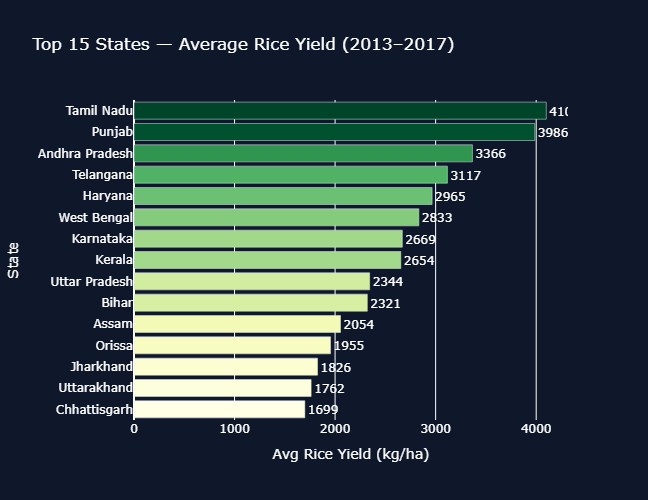

Chart saved!


In [37]:
#PLOTLY CHART: STATE YIELD COMPARISON

# Sort by the correct column name
# Sort by the correct column name
state_rice_sorted = state_rice.sort_values('avg_rice_yield_kgpha', ascending=True).tail(15)

fig = px.bar(
    state_rice_sorted,
    x='avg_rice_yield_kgpha',
    y='state',
    orientation='h',
    color='avg_rice_yield_kgpha',
    color_continuous_scale='YlGn',
    title='Top 15 States — Average Rice Yield (2013–2017)',
    labels={'avg_rice_yield_kgpha': 'Avg Rice Yield (kg/ha)', 'state': 'State'},
    text='avg_rice_yield_kgpha',
)
fig.update_layout(
    plot_bgcolor='#0F172A',
    paper_bgcolor='#0F172A',
    font_color='white',
    height=500,
    coloraxis_showscale=False,
)
fig.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig.show()
fig.write_html("chart_rice_yield_by_state.html")
print("Chart saved!")

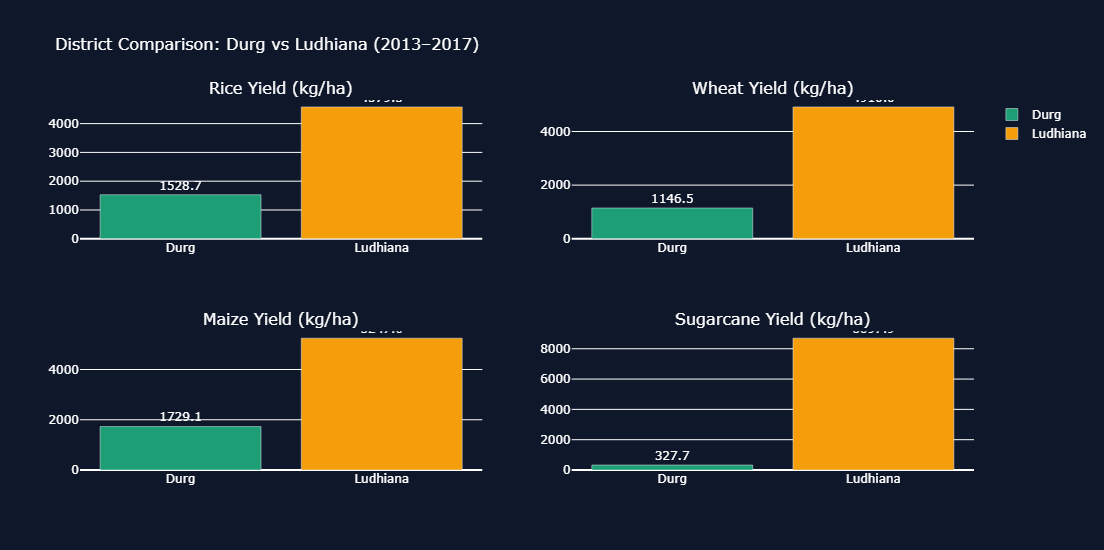


SUMMARY: Durg vs Ludhiana
  Rice        : Durg=1528.7  Ludhiana=4579.5
  Wheat       : Durg=1146.5  Ludhiana=4916.0
  Maize       : Durg=1729.1  Ludhiana=5247.0
  Sugarcane   : Durg=327.7  Ludhiana=8697.9


In [39]:
#DISTRICT COMAPARISON TOOL

def compare_districts(dist_A, dist_B):
    a = district_summary[district_summary['district'].str.lower() == dist_A.lower()]
    b = district_summary[district_summary['district'].str.lower() == dist_B.lower()]
    
    if a.empty:
        print(f"Not found: {dist_A}")
        print("Available:", district_summary['district'].sample(8).tolist())
        return
    if b.empty:
        print(f"Not found: {dist_B}")
        return
    
    a, b = a.iloc[0], b.iloc[0]
    
    crops   = ['Rice', 'Wheat', 'Maize', 'Sugarcane']
    cols    = ['avg_rice_yield','avg_wheat_yield','avg_maize_yield','avg_sugarcane']
    colors  = ['#1D9E75', '#F59E0B']
    
    fig = make_subplots(rows=2, cols=2,
        subplot_titles=[f'{c} Yield (kg/ha)' for c in crops])
    
    positions = [(1,1),(1,2),(2,1),(2,2)]
    for (crop, col, (row, c)) in zip(crops, cols, positions):
        va = round(a[col], 1) if not pd.isna(a[col]) else 0
        vb = round(b[col], 1) if not pd.isna(b[col]) else 0
        first = (row==1 and c==1)
        fig.add_trace(go.Bar(name=dist_A, x=[dist_A], y=[va],
            marker_color=colors[0], text=[va], textposition='outside',
            showlegend=first), row=row, col=c)
        fig.add_trace(go.Bar(name=dist_B, x=[dist_B], y=[vb],
            marker_color=colors[1], text=[vb], textposition='outside',
            showlegend=first), row=row, col=c)
    
    fig.update_layout(
        title=f'District Comparison: {dist_A} vs {dist_B} (2013–2017)',
        plot_bgcolor='#0F172A', paper_bgcolor='#0F172A',
        font_color='white', height=550, barmode='group',
        title_font_size=16,
    )
    fig.show()
    fig.write_html(f"compare_{dist_A}_vs_{dist_B}.html".replace(" ","_"))
    print(f"\nSUMMARY: {dist_A} vs {dist_B}")
    for crop, col in zip(crops, cols):
        va = round(a[col],1) if not pd.isna(a[col]) else 'No data'
        vb = round(b[col],1) if not pd.isna(b[col]) else 'No data'
        print(f"  {crop:12s}: {dist_A}={va}  {dist_B}={vb}")

# Run it — compare any two districts
# Use districts from dataset
compare_districts("Durg", "Ludhiana")

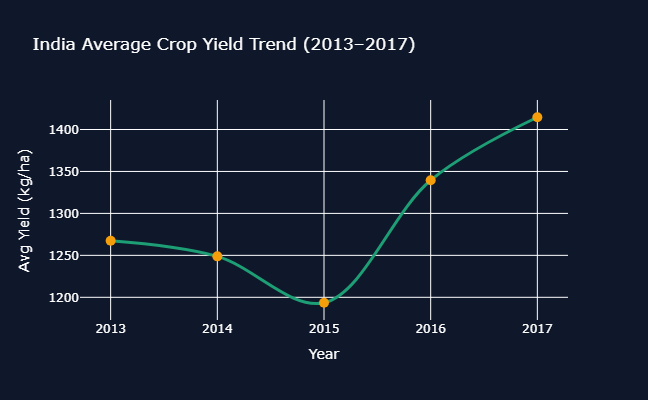

Trend chart saved!


In [40]:
fig2 = px.line(
    yearly,
    x='year',
    y='avg_crop_yield',
    title='India Average Crop Yield Trend (2013–2017)',
    labels={'avg_crop_yield': 'Avg Yield (kg/ha)', 'year': 'Year'},
    markers=True,
    line_shape='spline',
)
fig2.update_traces(
    line_color='#1D9E75',
    line_width=3,
    marker_size=10,
    marker_color='#F59E0B',
)
fig2.update_layout(
    plot_bgcolor='#0F172A',
    paper_bgcolor='#0F172A',
    font_color='white',
    height=400,
)
fig2.show()
fig2.write_html("chart_yield_trend.html")
print("Trend chart saved!")

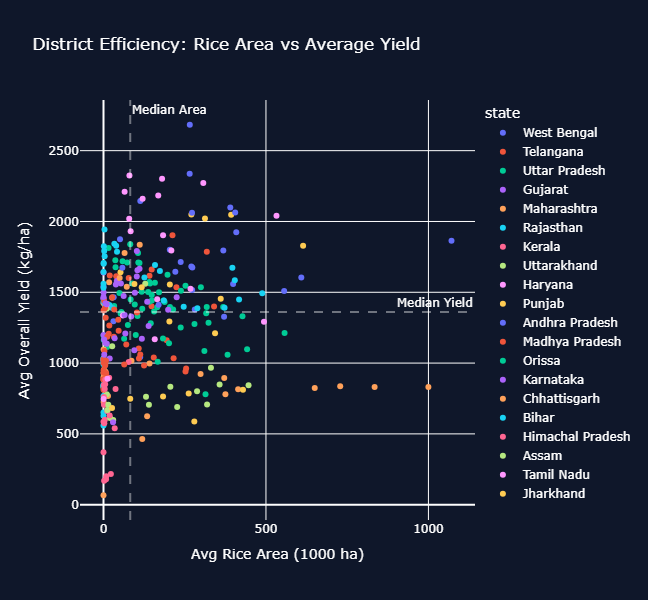

Scatter chart saved!


In [41]:
fig3 = px.scatter(
    district_summary.dropna(subset=['avg_yield','rice_area']),
    x='rice_area',
    y='avg_yield',
    color='state',
    hover_name='district',
    hover_data={'state': True, 'avg_yield': True, 'avg_rice_yield': True},
    title='District Efficiency: Rice Area vs Average Yield',
    labels={
        'rice_area': 'Avg Rice Area (1000 ha)',
        'avg_yield': 'Avg Overall Yield (kg/ha)',
    },
)

# Add median lines to create 4 quadrants
med_area  = district_summary['rice_area'].median()
med_yield = district_summary['avg_yield'].median()

fig3.add_hline(
    y=med_yield, line_dash='dash', line_color='white',
    opacity=0.4, annotation_text='Median Yield',
    annotation_font_color='white'
)
fig3.add_vline(
    x=med_area, line_dash='dash', line_color='white',
    opacity=0.4, annotation_text='Median Area',
    annotation_font_color='white'
)
fig3.update_layout(
    plot_bgcolor='#0F172A',
    paper_bgcolor='#0F172A',
    font_color='white',
    height=600,
)
fig3.show()
fig3.write_html("chart_scatter_efficiency.html")
print("Scatter chart saved!")

In [43]:
import os
os.makedirs("output", exist_ok=True)

# All your files are already saved in the same folder
# This cell just confirms what was created
files = [
    "india_crop_map.html",
    "chart_rice_yield_by_state.html",
    "chart_yield_trend.html",
    "chart_scatter_efficiency.html",
    "compare_Durg_vs_Ludhiana.html",
]

print("PROJECT OUTPUT FILES:")
print("-" * 40)
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) // 1024
        print(f"  ✅ {f} ({size} KB)")
    else:
        print(f"  ❌ {f} — not found yet")

print("\nOpen each .html file in your browser to see the result!")

PROJECT OUTPUT FILES:
----------------------------------------
  ✅ india_crop_map.html (62264 KB)
  ✅ chart_rice_yield_by_state.html (4461 KB)
  ✅ chart_yield_trend.html (4460 KB)
  ✅ chart_scatter_efficiency.html (4484 KB)
  ✅ compare_Durg_vs_Ludhiana.html (4462 KB)

Open each .html file in your browser to see the result!
